In [662]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("Environment Ready!")

Environment Ready!


In [663]:

players = pd.read_csv("../data/players.csv")
national_teams = pd.read_csv("../data/national_teams.csv")
games = pd.read_csv("../data/games.csv")
competitions = pd.read_csv("../data/competitions.csv")

print("Players:", players.shape)
print("National Teams:", national_teams.shape)
print("Games:", games.shape)
print("Competitions:", competitions.shape)

Players: (47716, 26)
National Teams: (118, 17)
Games: (88808, 23)
Competitions: (67, 11)


In [664]:
df = pd.read_csv("../data/national_teams.csv")

corrections = {
    "France": 1250000000,
    "England": 1500000000,
    "Spain": 1200000000
}

for team, value in corrections.items():
    df.loc[
        df["name"] == team,
        "total_market_value"
    ] = value

In [665]:
national_teams.head()

,national_team_id,name,team_code,country_id,country_name,country_code,confederation,team_image_url,squad_size,average_age,foreigners_number,foreigners_percentage,total_market_value,coach_name,fifa_ranking,last_season,url
0,10521,San Marino,san-marino,144,San Marino,SMR1,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,24,24.9,17,70.8,995000,NaN,211,2025,https://www.transfermarkt.co.uk/san-marino/sta...
1,10533,Andorra,andorra,5,Andorra,AND2,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,26,29.2,11,42.3,3380000,NaN,173,2025,https://www.transfermarkt.co.uk/andorra/starts...
2,11953,Montenegro,montenegro,216,Montenegro,MNE1,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,26,28.3,24,92.3,60130001,NaN,81,2025,https://www.transfermarkt.co.uk/montenegro/sta...
3,13342,Guatemala,guatemala,58,Guatemala,GU1A,CONCACAF,https://tmssl.akamaized.net//images/flagge/hea...,21,25.2,6,28.6,5330000,NaN,96,2025,https://www.transfermarkt.co.uk/guatemala/star...
4,13497,Uganda,uganda,176,Uganda,UGL1,CAF,https://tmssl.akamaized.net//images/flagge/hea...,28,28.0,23,82.1,8700000,NaN,88,2025,https://www.transfermarkt.co.uk/uganda/startse...


# World Cup 2026 Prediction Project
## Data Loading and Inspection

In [666]:
players = pd.read_csv("../data/players.csv")
national_teams = pd.read_csv("../data/national_teams.csv")
games = pd.read_csv("../data/games.csv")
competitions = pd.read_csv("../data/competitions.csv")

In [667]:
print("=== PLAYERS ===")
players.info()

players.head(3)

=== PLAYERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47716 entries, 0 to 47715
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             47716 non-null  int64  
 1   first_name                            44621 non-null  object 
 2   last_name                             47716 non-null  object 
 3   name                                  47716 non-null  object 
 4   last_season                           47716 non-null  int64  
 5   current_club_id                       47716 non-null  int64  
 6   player_code                           47716 non-null  object 
 7   country_of_birth                      42551 non-null  object 
 8   city_of_birth                         42827 non-null  object 
 9   country_of_citizenship                47443 non-null  object 
 10  date_of_birth                         47667 non-null  object 
 11 

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0


In [668]:
print("=== NATIONAL TEAMS ===")
national_teams.info()

national_teams.head(3)

=== NATIONAL TEAMS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   national_team_id       118 non-null    int64  
 1   name                   118 non-null    object 
 2   team_code              118 non-null    object 
 3   country_id             118 non-null    int64  
 4   country_name           118 non-null    object 
 5   country_code           118 non-null    object 
 6   confederation          117 non-null    object 
 7   team_image_url         118 non-null    object 
 8   squad_size             118 non-null    int64  
 9   average_age            118 non-null    float64
 10  foreigners_number      118 non-null    int64  
 11  foreigners_percentage  113 non-null    float64
 12  total_market_value     118 non-null    int64  
 13  coach_name             0 non-null      float64
 14  fifa_ranking           118 non-null

,national_team_id,name,team_code,country_id,country_name,country_code,confederation,team_image_url,squad_size,average_age,foreigners_number,foreigners_percentage,total_market_value,coach_name,fifa_ranking,last_season,url
0,10521,San Marino,san-marino,144,San Marino,SMR1,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,24,24.9,17,70.8,995000,NaN,211,2025,https://www.transfermarkt.co.uk/san-marino/sta...
1,10533,Andorra,andorra,5,Andorra,AND2,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,26,29.2,11,42.3,3380000,NaN,173,2025,https://www.transfermarkt.co.uk/andorra/starts...
2,11953,Montenegro,montenegro,216,Montenegro,MNE1,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,26,28.3,24,92.3,60130001,NaN,81,2025,https://www.transfermarkt.co.uk/montenegro/sta...


In [669]:
print("=== COMPETITIONS ===")
competitions.info()

competitions.head(3)

=== COMPETITIONS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   competition_id        67 non-null     object 
 1   competition_code      67 non-null     object 
 2   name                  67 non-null     object 
 3   sub_type              67 non-null     object 
 4   type                  67 non-null     object 
 5   country_id            67 non-null     int64  
 6   country_name          54 non-null     object 
 7   domestic_league_code  54 non-null     object 
 8   confederation         67 non-null     object 
 9   total_clubs           51 non-null     float64
 10  url                   67 non-null     object 
dtypes: float64(1), int64(1), object(9)
memory usage: 5.9+ KB


,competition_id,competition_code,name,sub_type,type,country_id,country_name,domestic_league_code,confederation,total_clubs,url
0,A1,bundesliga,bundesliga,first_tier,domestic_league,127,Austria,A1,europa,12.0,https://www.transfermarkt.co.uk/bundesliga/sta...
1,AFAC,afc-asian-cup,afc-asian-cup,afc_asian_cup,national_team_competition,-1,NaN,NaN,asien,NaN,https://www.transfermarkt.co.uk/afc-asian-cup/...
2,AFCN,africa-cup-of-nations,africa-cup-of-nations,africa_cup_of_nations,national_team_competition,-1,NaN,NaN,afrika,NaN,https://www.transfermarkt.co.uk/africa-cup-of-...


In [670]:
national_teams.isnull().sum()

national_team_id           0
name                       0
team_code                  0
country_id                 0
country_name               0
country_code               0
confederation              1
team_image_url             0
squad_size                 0
average_age                0
foreigners_number          0
foreigners_percentage      5
total_market_value         0
coach_name               118
fifa_ranking               0
last_season                0
url                        0
dtype: int64

In [671]:
len(national_teams)

118

In [672]:
df = national_teams.copy()

df.head()

,national_team_id,name,team_code,country_id,country_name,country_code,confederation,team_image_url,squad_size,average_age,foreigners_number,foreigners_percentage,total_market_value,coach_name,fifa_ranking,last_season,url
0,10521,San Marino,san-marino,144,San Marino,SMR1,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,24,24.9,17,70.8,995000,NaN,211,2025,https://www.transfermarkt.co.uk/san-marino/sta...
1,10533,Andorra,andorra,5,Andorra,AND2,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,26,29.2,11,42.3,3380000,NaN,173,2025,https://www.transfermarkt.co.uk/andorra/starts...
2,11953,Montenegro,montenegro,216,Montenegro,MNE1,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,26,28.3,24,92.3,60130001,NaN,81,2025,https://www.transfermarkt.co.uk/montenegro/sta...
3,13342,Guatemala,guatemala,58,Guatemala,GU1A,CONCACAF,https://tmssl.akamaized.net//images/flagge/hea...,21,25.2,6,28.6,5330000,NaN,96,2025,https://www.transfermarkt.co.uk/guatemala/star...
4,13497,Uganda,uganda,176,Uganda,UGL1,CAF,https://tmssl.akamaized.net//images/flagge/hea...,28,28.0,23,82.1,8700000,NaN,88,2025,https://www.transfermarkt.co.uk/uganda/startse...


## Feature Engineering & Team Strength Rating

In [673]:
from sklearn.preprocessing import MinMaxScaler

In [674]:
df['total_market_value'] = df['total_market_value'].fillna(0)

In [675]:
df['total_market_value'].isnull().sum()

np.int64(0)

In [676]:
#Higher number = stronger team
max_ranking = df['fifa_ranking'].max()

df['inverse_fifa'] = (
    max_ranking - df['fifa_ranking']
) + 1

In [677]:
#Normalize FIFA Ranking
scaler = MinMaxScaler()

df['norm_fifa'] = scaler.fit_transform(
    df[['inverse_fifa']]
)

In [678]:
df[['name', 'fifa_ranking', 'norm_fifa']].head()

,name,fifa_ranking,norm_fifa
0,San Marino,211,0.000000
1,Andorra,173,0.180952
2,Montenegro,81,0.619048
3,Guatemala,96,0.547619
4,Uganda,88,0.585714


In [679]:
#Normalize Market Value
df['norm_value'] = scaler.fit_transform(
    df[['total_market_value']]
)

In [680]:
df[['name', 'total_market_value', 'norm_value']].head()

,name,total_market_value,norm_value
0,San Marino,995000,0.000000
1,Andorra,3380000,0.001570
2,Montenegro,60130001,0.038930
3,Guatemala,5330000,0.002854
4,Uganda,8700000,0.005072


In [681]:
df['team_rating'] = (
    df['norm_fifa'] * 0.4
    +
    df['norm_value'] * 0.6
)

In [682]:
df[
    [
        'name',
        'fifa_ranking',
        'total_market_value',
        'team_rating'
    ]
].head()

,name,fifa_ranking,total_market_value,team_rating
0,San Marino,211,995000,0.000000
1,Andorra,173,3380000,0.073323
2,Montenegro,81,60130001,0.270977
3,Guatemala,96,5330000,0.220760
4,Uganda,88,8700000,0.237329


In [683]:
top20 = df.sort_values(
    by='team_rating',
    ascending=False
)[
    [
        'name',
        'fifa_ranking',
        'total_market_value',
        'team_rating'
    ]
].head(20)

top20

,name,fifa_ranking,total_market_value,team_rating
32,France,1,1520000000,1.000000
28,England,4,1400000000,0.946886
30,Spain,2,1220000000,0.879597
29,Portugal,5,864500000,0.733461
31,Italy,12,833500000,0.707883
46,Brazil,6,778500000,0.697587
44,Argentina,3,761200012,0.696468
34,Netherlands,7,766000000,0.690745
27,Germany,10,773500000,0.687993
37,Belgium,9,534200012,0.595375


In [684]:
top20_display = top20.copy()

top20_display['total_market_value'] = (
    top20_display['total_market_value']
    .apply(
        lambda x:
        f"€{x/1e6:.1f}M"
        if x < 1e9
        else f"€{x/1e9:.2f}B"
    )
)

top20_display

,name,fifa_ranking,total_market_value,team_rating
32,France,1,€1.52B,1.000000
28,England,4,€1.40B,0.946886
30,Spain,2,€1.22B,0.879597
29,Portugal,5,€864.5M,0.733461
31,Italy,12,€833.5M,0.707883
46,Brazil,6,€778.5M,0.697587
44,Argentina,3,€761.2M,0.696468
34,Netherlands,7,€766.0M,0.690745
27,Germany,10,€773.5M,0.687993
37,Belgium,9,€534.2M,0.595375


In [685]:
df.to_csv(
    "../outputs/national_teams_with_ratings.csv",
    index=False
)

In [686]:
def prepare_team_data(df):

    mapping = {
        'czech republic': 'czechia',
        'republic of ireland': 'ireland',
        'united states': 'usa',
        'south korea': 'republic of korea',
        'ivory coast': "côte d'ivoire",
        'netherlands': 'netherlands',
        'turkiye': 'turkiye'
    }

    def clean_name(name):
        n = str(name).strip().lower()
        return mapping.get(n, n)

    df = df.copy()
    df['name_clean'] = df['name'].apply(clean_name)

    return df

In [687]:
df_ratings = prepare_team_data(df)

df_ratings[['name', 'name_clean']].head()

,name,name_clean
0,San Marino,san marino
1,Andorra,andorra
2,Montenegro,montenegro
3,Guatemala,guatemala
4,Uganda,uganda


In [688]:
import numpy as np

def match_probabilities(team_a, team_b, df_data):

    team_a = str(team_a).strip().lower()
    team_b = str(team_b).strip().lower()

    row_a = df_data[df_data['name_clean'] == team_a]
    row_b = df_data[df_data['name_clean'] == team_b]

    default_rating = df_data['team_rating'].median()

    rating_a = (
        row_a['team_rating'].values[0]
        if not row_a.empty
        else default_rating
    )

    rating_b = (
        row_b['team_rating'].values[0]
        if not row_b.empty
        else default_rating
    )

    diff = rating_a - rating_b

    gamma = 5

    prob_a_base = 1 / (1 + np.exp(-gamma * diff))

    prob_draw = 0.28 * np.exp(-abs(gamma * diff))

    prob_a = prob_a_base * (1 - prob_draw)

    prob_b = (1 - prob_a_base) * (1 - prob_draw)

    return prob_a, prob_draw, prob_b

In [689]:
match_probabilities(
    "brazil",
    "argentina",
    df_ratings
)

(np.float64(0.36179060349943337),
 np.float64(0.2784375932676248),
 np.float64(0.3597718032329418))

In [690]:
def simulate_group_match(team_a, team_b, df_data):

    p_a, p_draw, p_b = match_probabilities(
        team_a,
        team_b,
        df_data
    )

    result = np.random.choice(
        ['A', 'DRAW', 'B'],
        p=[p_a, p_draw, p_b]
    )

    return result

In [691]:
simulate_group_match(
    "brazil",
    "argentina",
    df_ratings
)

np.str_('B')

In [692]:
results = []

for _ in range(20):

    results.append(
        simulate_group_match(
            "brazil",
            "argentina",
            df_ratings
        )
    )

results

[np.str_('DRAW'),
 np.str_('A'),
 np.str_('B'),
 np.str_('B'),
 np.str_('A'),
 np.str_('DRAW'),
 np.str_('DRAW'),
 np.str_('DRAW'),
 np.str_('DRAW'),
 np.str_('A'),
 np.str_('A'),
 np.str_('B'),
 np.str_('B'),
 np.str_('B'),
 np.str_('B'),
 np.str_('A'),
 np.str_('B'),
 np.str_('B'),
 np.str_('A'),
 np.str_('DRAW')]

In [693]:
p_a, p_draw, p_b = match_probabilities(
    "brazil",
    "argentina",
    df_ratings
)

print("Brazil Win :", round(p_a * 100, 2), "%")
print("Draw       :", round(p_draw * 100, 2), "%")
print("Argentina  :", round(p_b * 100, 2), "%")

Brazil Win : 36.18 %
Draw       : 27.84 %
Argentina  : 35.98 %


In [694]:
def simulate_group_stage(groups, df_data):

    final_tables = {}

    for group_name, teams in groups.items():

        points = {
            team: 0
            for team in teams
        }

        for i in range(len(teams)):

            for j in range(i + 1, len(teams)):

                team1 = teams[i]
                team2 = teams[j]

                p_win, p_draw, p_loss = match_probabilities(
                    team1,
                    team2,
                    df_data
                )

                result = np.random.choice(
                    ['TEAM1', 'DRAW', 'TEAM2'],
                    p=[p_win, p_draw, p_loss]
                )

                if result == 'TEAM1':
                    points[team1] += 3

                elif result == 'DRAW':
                    points[team1] += 1
                    points[team2] += 1

                else:
                    points[team2] += 3

        standings = sorted(
            points.items(),
            key=lambda x: x[1],
            reverse=True
        )

        final_tables[group_name] = standings

    return final_tables

In [695]:
test_group = {
    "Group A": [
        "Brazil",
        "Argentina",
        "Germany",
        "Japan"
    ]
}

In [696]:
results = simulate_group_stage(
    test_group,
    df_ratings
)

results

{'Group A': [('Argentina', 6), ('Brazil', 4), ('Japan', 4), ('Germany', 3)]}

In [697]:
for group, table in results.items():

    print(f"\n{group}")

    for pos, (team, pts) in enumerate(table, start=1):

        print(
            f"{pos}. {team:<15} {pts} pts"
        )


Group A
1. Argentina       6 pts
2. Brazil          4 pts
3. Japan           4 pts
4. Germany         3 pts


In [698]:
groups_2026 = {

    'Group A': [
        'Mexico',
        'South Africa',
        'South Korea',
        'Czechia'
    ],

    'Group B': [
        'Canada',
        'Switzerland',
        'Qatar',
        'Bosnia and Herzegovina'
    ],

    'Group C': [
        'Brazil',
        'Morocco',
        'Haiti',
        'Scotland'
    ],

    'Group D': [
        'USA',
        'Paraguay',
        'Australia',
        'Turkiye'
    ],

    'Group E': [
        'Germany',
        'Curacao',
        'Ivory Coast',
        'Ecuador'
    ],

    'Group F': [
        'Netherlands',
        'Japan',
        'Tunisia',
        'Sweden'
    ],

    'Group G': [
        'Belgium',
        'Egypt',
        'Iran',
        'New Zealand'
    ],

    'Group H': [
        'Spain',
        'Cabo Verde',
        'Saudi Arabia',
        'Uruguay'
    ],

    'Group I': [
        'France',
        'Senegal',
        'Norway',
        'Iraq'
    ],

    'Group J': [
        'Argentina',
        'Algeria',
        'Austria',
        'Jordan'
    ],

    'Group K': [
        'Portugal',
        'Uzbekistan',
        'Colombia',
        'Congo DR'
    ],

    'Group L': [
        'England',
        'Croatia',
        'Ghana',
        'Panama'
    ]
}

In [699]:
group_results = simulate_group_stage(
    groups_2026,
    df_ratings
)

In [700]:
for group, standings in group_results.items():

    print("\n" + "=" * 40)
    print(group)
    print("=" * 40)

    for pos, (team, pts) in enumerate(
        standings,
        start=1
    ):

        print(
            f"{pos}. {team:<22} {pts} pts"
        )


Group A
1. Mexico                 5 pts
2. South Africa           5 pts
3. South Korea            4 pts
4. Czechia                1 pts

Group B
1. Switzerland            9 pts
2. Qatar                  4 pts
3. Bosnia and Herzegovina 2 pts
4. Canada                 1 pts

Group C
1. Brazil                 9 pts
2. Morocco                3 pts
3. Haiti                  3 pts
4. Scotland               3 pts

Group D
1. Paraguay               5 pts
2. Turkiye                5 pts
3. USA                    4 pts
4. Australia              1 pts

Group E
1. Germany                6 pts
2. Ivory Coast            6 pts
3. Curacao                3 pts
4. Ecuador                3 pts

Group F
1. Netherlands            6 pts
2. Japan                  4 pts
3. Sweden                 4 pts
4. Tunisia                3 pts

Group G
1. Egypt                  9 pts
2. New Zealand            4 pts
3. Belgium                3 pts
4. Iran                   1 pts

Group H
1. Spain                  6 pts


In [701]:
group_results

{'Group A': [('Mexico', 5),
  ('South Africa', 5),
  ('South Korea', 4),
  ('Czechia', 1)],
 'Group B': [('Switzerland', 9),
  ('Qatar', 4),
  ('Bosnia and Herzegovina', 2),
  ('Canada', 1)],
 'Group C': [('Brazil', 9), ('Morocco', 3), ('Haiti', 3), ('Scotland', 3)],
 'Group D': [('Paraguay', 5), ('Turkiye', 5), ('USA', 4), ('Australia', 1)],
 'Group E': [('Germany', 6),
  ('Ivory Coast', 6),
  ('Curacao', 3),
  ('Ecuador', 3)],
 'Group F': [('Netherlands', 6), ('Japan', 4), ('Sweden', 4), ('Tunisia', 3)],
 'Group G': [('Egypt', 9), ('New Zealand', 4), ('Belgium', 3), ('Iran', 1)],
 'Group H': [('Spain', 6),
  ('Uruguay', 6),
  ('Cabo Verde', 4),
  ('Saudi Arabia', 1)],
 'Group I': [('France', 6), ('Senegal', 6), ('Norway', 6), ('Iraq', 0)],
 'Group J': [('Argentina', 9), ('Austria', 4), ('Algeria', 3), ('Jordan', 1)],
 'Group K': [('Portugal', 9),
  ('Congo DR', 6),
  ('Colombia', 3),
  ('Uzbekistan', 0)],
 'Group L': [('England', 9), ('Croatia', 4), ('Panama', 2), ('Ghana', 1)]}

In [702]:
def simulate_knockout_match(team1, team2, df_data):

    team1_data = df_data[
        df_data['name_clean'] == team1.lower()
    ]

    team2_data = df_data[
        df_data['name_clean'] == team2.lower()
    ]

    default_rating = df_data['team_rating'].median()

    rating1 = (
        team1_data['team_rating'].values[0]
        if not team1_data.empty
        else default_rating
    )

    rating2 = (
        team2_data['team_rating'].values[0]
        if not team2_data.empty
        else default_rating
    )

    diff = rating1 - rating2

    probability_team1 = (
        1 /
        (1 + np.exp(-5 * diff))
    )

    probability_team2 = (
        1 - probability_team1
    )

    winner = np.random.choice(
        [team1, team2],
        p=[
            probability_team1,
            probability_team2
        ]
    )

    return winner

In [703]:
import pandas as pd

def get_qualified_teams(
    group_results,
    df_data
):

    first_place = {}
    second_place = {}

    third_place = []

    for group, standings in group_results.items():

        first_place[group] = standings[0][0]
        second_place[group] = standings[1][0]

        team_3rd = standings[2][0]
        points_3rd = standings[2][1]

        rating_3rd = (
            df_data[
                df_data['name_clean']
                ==
                team_3rd.lower()
            ]['team_rating']
            .values[0]
            if team_3rd.lower()
            in df_data['name_clean'].values
            else 0
        )

        third_place.append({
            'team': team_3rd,
            'points': points_3rd,
            'rating': rating_3rd
        })

    third_df = pd.DataFrame(
        third_place
    )

    third_df = third_df.sort_values(
        by=['points', 'rating'],
        ascending=False
    )

    best_thirds = list(
        third_df['team'].head(8)
    )

    qualified = (
        list(first_place.values())
        +
        list(second_place.values())
        +
        best_thirds
    )

    return qualified

In [704]:
qualified_teams = get_qualified_teams(
    group_results,
    df_ratings
)

len(qualified_teams)

32

In [705]:
def run_knockout_stage(
    qualified_teams,
    df_data
):

    teams = qualified_teams.copy()

    np.random.shuffle(teams)

    rounds = [
        "Round of 32",
        "Round of 16",
        "Quarterfinals",
        "Semifinals",
        "Final"
    ]

    for round_name in rounds:

        print("\n")
        print("=" * 50)
        print(round_name)
        print("=" * 50)

        winners = []

        for i in range(
            0,
            len(teams),
            2
        ):

            team1 = teams[i]
            team2 = teams[i + 1]

            winner = simulate_knockout_match(
                team1,
                team2,
                df_data
            )

            print(
                f"{team1} vs {team2} -> {winner}"
            )

            winners.append(winner)

        teams = winners

        if len(teams) == 1:

            print("\n")
            print(
                f"🏆 Champion: {teams[0]}"
            )

            return teams[0]

In [706]:
champion = run_knockout_stage(
    qualified_teams,
    df_ratings
)



Round of 32
South Africa vs Algeria -> Algeria
Egypt vs Brazil -> Brazil
Croatia vs Switzerland -> Croatia
England vs Colombia -> England
Argentina vs South Korea -> Argentina
New Zealand vs Portugal -> Portugal
Turkiye vs USA -> Turkiye
Austria vs Paraguay -> Paraguay
Norway vs Belgium -> Belgium
Senegal vs Ivory Coast -> Ivory Coast
Mexico vs Germany -> Germany
Uruguay vs Cabo Verde -> Cabo Verde
France vs Spain -> France
Qatar vs Sweden -> Sweden
Morocco vs Japan -> Morocco
Netherlands vs Congo DR -> Netherlands


Round of 16
Algeria vs Brazil -> Algeria
Croatia vs England -> England
Argentina vs Portugal -> Portugal
Turkiye vs Paraguay -> Turkiye
Belgium vs Ivory Coast -> Belgium
Germany vs Cabo Verde -> Germany
France vs Sweden -> France
Morocco vs Netherlands -> Netherlands


Quarterfinals
Algeria vs England -> England
Portugal vs Turkiye -> Portugal
Belgium vs Germany -> Germany
France vs Netherlands -> France


Semifinals
England vs Portugal -> Portugal
Germany vs France -> F

In [707]:
def run_full_world_cup(
    groups,
    df_data
):

    group_results = simulate_group_stage(
        groups,
        df_data
    )

    qualified = get_qualified_teams(
        group_results,
        df_data
    )

    champion = run_knockout_stage(
        qualified,
        df_data
    )

    return champion

In [708]:
champion = run_full_world_cup(
    groups_2026,
    df_ratings
)

print(champion)



Round of 32
Morocco vs Portugal -> Morocco
Colombia vs Senegal -> Senegal
Brazil vs Ecuador -> Brazil
Uzbekistan vs Croatia -> Croatia
Switzerland vs Argentina -> Switzerland
Germany vs USA -> USA
Netherlands vs France -> Netherlands
Panama vs England -> England
Australia vs Uruguay -> Australia
Paraguay vs Austria -> Austria
Mexico vs Japan -> Japan
Bosnia and Herzegovina vs Belgium -> Belgium
Algeria vs Egypt -> Egypt
Norway vs Iran -> Iran
Spain vs Czechia -> Spain
Curacao vs Canada -> Canada


Round of 16
Morocco vs Senegal -> Senegal
Brazil vs Croatia -> Croatia
Switzerland vs USA -> USA
Netherlands vs England -> England
Australia vs Austria -> Austria
Japan vs Belgium -> Japan
Egypt vs Iran -> Egypt
Spain vs Canada -> Spain


Quarterfinals
Senegal vs Croatia -> Senegal
USA vs England -> England
Austria vs Japan -> Japan
Egypt vs Spain -> Spain


Semifinals
Senegal vs England -> England
Japan vs Spain -> Spain


Final
England vs Spain -> England


🏆 Champion: England
England


In [709]:
run_full_world_cup(
    groups_2026,
    df_ratings
)



Round of 32
Qatar vs South Korea -> Qatar
Brazil vs Colombia -> Brazil
Cabo Verde vs Paraguay -> Paraguay
Scotland vs Czechia -> Scotland
Portugal vs Netherlands -> Netherlands
Croatia vs Japan -> Croatia
Iran vs Spain -> Spain
Belgium vs Uruguay -> Belgium
Algeria vs Norway -> Norway
Senegal vs England -> Senegal
Germany vs Austria -> Germany
Sweden vs Turkiye -> Turkiye
France vs Morocco -> France
South Africa vs Ecuador -> Ecuador
USA vs Argentina -> Argentina
Switzerland vs Panama -> Switzerland


Round of 16
Qatar vs Brazil -> Brazil
Paraguay vs Scotland -> Paraguay
Netherlands vs Croatia -> Netherlands
Spain vs Belgium -> Spain
Norway vs Senegal -> Senegal
Germany vs Turkiye -> Germany
France vs Ecuador -> France
Argentina vs Switzerland -> Argentina


Quarterfinals
Brazil vs Paraguay -> Brazil
Netherlands vs Spain -> Spain
Senegal vs Germany -> Senegal
France vs Argentina -> France


Semifinals
Brazil vs Spain -> Spain
Senegal vs France -> France


Final
Spain vs France -> Fra

np.str_('France')

### Monte Carlo Simulation

In [710]:
def run_knockout_silent(
    qualified_teams,
    df_data
):

    teams = qualified_teams.copy()

    np.random.shuffle(teams)

    while len(teams) > 1:

        winners = []

        for i in range(
            0,
            len(teams),
            2
        ):

            winner = simulate_knockout_match(
                teams[i],
                teams[i + 1],
                df_data
            )

            winners.append(winner)

        teams = winners

    return teams[0]

In [711]:
def simulate_world_cup(
    groups,
    df_data
):

    group_results = simulate_group_stage(
        groups,
        df_data
    )

    qualified = get_qualified_teams(
        group_results,
        df_data
    )

    champion = run_knockout_silent(
        qualified,
        df_data
    )

    return champion

In [712]:
champion = simulate_world_cup(
    groups_2026,
    df_ratings
)

print(champion)

France


In [713]:
def monte_carlo_world_cup(
    groups,
    df_data,
    n_simulations=10000
):

    champions = {}

    print(
        f"Running {n_simulations} simulations..."
    )

    for i in range(n_simulations):

        if (i + 1) % 100 == 0:

            print(
                f"Completed {i+1} simulations"
            )

        champion = simulate_world_cup(
            groups,
            df_data
        )

        champions[champion] = (
            champions.get(champion, 0)
            + 1
        )

    return champions

In [714]:
champions_count = monte_carlo_world_cup(
    groups_2026,
    df_ratings,
    n_simulations=10000
)

Running 10000 simulations...
Completed 100 simulations
Completed 200 simulations
Completed 300 simulations
Completed 400 simulations
Completed 500 simulations
Completed 600 simulations
Completed 700 simulations
Completed 800 simulations
Completed 900 simulations
Completed 1000 simulations
Completed 1100 simulations
Completed 1200 simulations
Completed 1300 simulations
Completed 1400 simulations
Completed 1500 simulations
Completed 1600 simulations
Completed 1700 simulations
Completed 1800 simulations
Completed 1900 simulations
Completed 2000 simulations
Completed 2100 simulations
Completed 2200 simulations
Completed 2300 simulations
Completed 2400 simulations
Completed 2500 simulations
Completed 2600 simulations
Completed 2700 simulations
Completed 2800 simulations
Completed 2900 simulations
Completed 3000 simulations
Completed 3100 simulations
Completed 3200 simulations
Completed 3300 simulations
Completed 3400 simulations
Completed 3500 simulations
Completed 3600 simulations
Complete

In [715]:
# Create DataFrame from simulation results
results_df = pd.DataFrame(
    list(champions_count.items()),
    columns=["Team", "Titles"]
)

# Number of simulations you ran
N_SIMULATIONS = 10000

# Calculate probabilities
results_df["Title Probability (%)"] = (
    results_df["Titles"] / N_SIMULATIONS
) * 100

# Sort
results_df = results_df.sort_values(
    by="Title Probability (%)",
    ascending=False
)

# Display
results_df.head(20)

,Team,Titles,Title Probability (%)
0,France,3704,37.04
2,England,2624,26.24
1,Spain,1664,16.64
7,Portugal,455,4.55
9,Brazil,311,3.11
11,Argentina,291,2.91
6,Netherlands,263,2.63
5,Germany,232,2.32
4,Belgium,89,0.89
8,Morocco,60,0.60


In [716]:
results_df = results_df.sort_values(
    by="Title Probability (%)",
    ascending=False
)

results_df.head(20)

,Team,Titles,Title Probability (%)
0,France,3704,37.04
2,England,2624,26.24
1,Spain,1664,16.64
7,Portugal,455,4.55
9,Brazil,311,3.11
11,Argentina,291,2.91
6,Netherlands,263,2.63
5,Germany,232,2.32
4,Belgium,89,0.89
8,Morocco,60,0.60


In [717]:
results_df[
    "Title Probability (%)"
] = (
    results_df[
        "Title Probability (%)"
    ]
    .round(2)
)

In [718]:
results_df

,Team,Titles,Title Probability (%)
0,France,3704,37.04
2,England,2624,26.24
1,Spain,1664,16.64
7,Portugal,455,4.55
9,Brazil,311,3.11
11,Argentina,291,2.91
6,Netherlands,263,2.63
5,Germany,232,2.32
4,Belgium,89,0.89
8,Morocco,60,0.60


In [719]:
results_df.to_csv(
    "../outputs/world_cup_2026_probabilities.csv",
    index=False
)

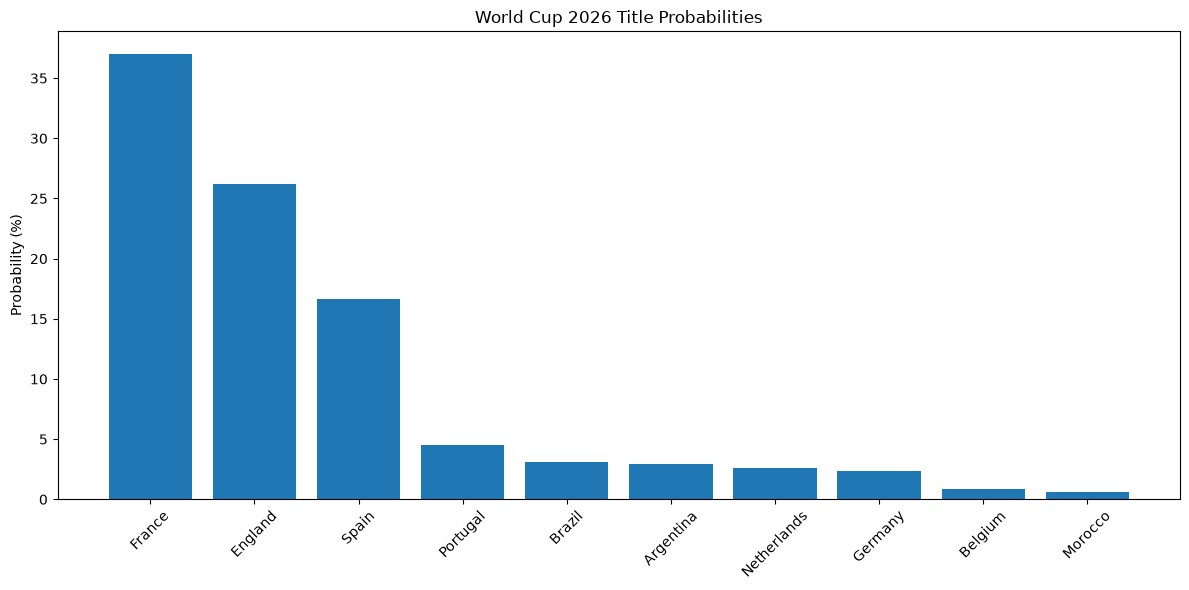

In [720]:
import matplotlib.pyplot as plt

top10 = results_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["Team"],
    top10["Title Probability (%)"]
)

plt.xticks(rotation=45)

plt.ylabel(
    "Probability (%)"
)

plt.title(
    "World Cup 2026 Title Probabilities"
)

plt.tight_layout()

plt.show()

## Create a Score Generator

In [721]:
def generate_match_score(
    team_a,
    team_b,
    df_data
):
    
    p_a, p_draw, p_b = match_probabilities(
        team_a,
        team_b,
        df_data
    )

    result = np.random.choice(
        ["A", "DRAW", "B"],
        p=[p_a, p_draw, p_b]
    )

    if result == "DRAW":

        goals = np.random.choice(
            [0, 1, 2, 3],
            p=[0.20, 0.45, 0.25, 0.10]
        )

        return goals, goals

    elif result == "A":

        goals_a = np.random.choice(
            [1,2,3,4,5],
            p=[0.30,0.35,0.20,0.10,0.05]
        )

        goals_b = np.random.randint(
            0,
            goals_a
        )

        return goals_a, goals_b

    else:

        goals_b = np.random.choice(
            [1,2,3,4,5],
            p=[0.30,0.35,0.20,0.10,0.05]
        )

        goals_a = np.random.randint(
            0,
            goals_b
        )

        return goals_a, goals_b

In [722]:
for _ in range(10):
    print(
        generate_match_score(
            "Brazil",
            "Argentina",
            df_ratings
        )
    )

(np.int64(0), np.int64(0))
(0, np.int64(4))
(np.int64(2), 1)
(2, np.int64(3))
(0, np.int64(3))
(np.int64(3), 1)
(1, np.int64(3))
(np.int64(1), np.int64(1))
(np.int64(2), 0)
(np.int64(2), 1)


In [723]:
def create_group_table(teams):

    table = {}

    for team in teams:

        table[team] = {

            "points": 0,
            "gf": 0,
            "ga": 0,
            "gd": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0
        }

    return table

In [724]:
def simulate_group_stage_realistic(
    groups,
    df_data
):

    all_groups = {}

    for group_name, teams in groups.items():

        table = create_group_table(
            teams
        )

        for i in range(len(teams)):

            for j in range(i + 1, len(teams)):

                team1 = teams[i]
                team2 = teams[j]

                g1, g2 = generate_match_score(
                    team1,
                    team2,
                    df_data
                )

                table[team1]["gf"] += g1
                table[team1]["ga"] += g2

                table[team2]["gf"] += g2
                table[team2]["ga"] += g1

                if g1 > g2:

                    table[team1]["points"] += 3
                    table[team1]["wins"] += 1
                    table[team2]["losses"] += 1

                elif g2 > g1:

                    table[team2]["points"] += 3
                    table[team2]["wins"] += 1
                    table[team1]["losses"] += 1

                else:

                    table[team1]["points"] += 1
                    table[team2]["points"] += 1

                    table[team1]["draws"] += 1
                    table[team2]["draws"] += 1

        for team in teams:

            table[team]["gd"] = (
                table[team]["gf"]
                -
                table[team]["ga"]
            )

        standings = sorted(
            table.items(),
            key=lambda x: (
                x[1]["points"],
                x[1]["gd"],
                x[1]["gf"]
            ),
            reverse=True
        )

        all_groups[group_name] = standings

    return all_groups

In [725]:
results = simulate_group_stage_realistic(
    {
        "Group A":[
            "Brazil",
            "Argentina",
            "Germany",
            "Japan"
        ]
    },
    df_ratings
)

In [726]:
results

{'Group A': [('Germany',
   {'points': 7,
    'gf': np.int64(7),
    'ga': np.int64(4),
    'gd': np.int64(3),
    'wins': 2,
    'draws': 1,
    'losses': 0}),
  ('Brazil',
   {'points': 5,
    'gf': np.int64(3),
    'ga': np.int64(2),
    'gd': np.int64(1),
    'wins': 1,
    'draws': 2,
    'losses': 0}),
  ('Argentina',
   {'points': 4,
    'gf': np.int64(2),
    'ga': np.int64(2),
    'gd': np.int64(0),
    'wins': 1,
    'draws': 1,
    'losses': 1}),
  ('Japan',
   {'points': 0,
    'gf': 3,
    'ga': np.int64(7),
    'gd': np.int64(-4),
    'wins': 0,
    'draws': 0,
    'losses': 3})]}

In [727]:
for group, standings in results.items():

    print(f"\n{group}")

    for pos, (team, stats) in enumerate(
        standings,
        start=1
    ):

        print(
            f"{pos}. {team:<15}"
            f" Pts:{stats['points']}"
            f" GD:{stats['gd']}"
            f" GF:{stats['gf']}"
        )


Group A
1. Germany         Pts:7 GD:3 GF:7
2. Brazil          Pts:5 GD:1 GF:3
3. Argentina       Pts:4 GD:0 GF:2
4. Japan           Pts:0 GD:-4 GF:3


In [728]:
HOSTS = [
    "usa",
    "canada",
    "mexico"
]

def apply_home_advantage(
    team_name,
    rating
):
    
    if team_name.lower() in HOSTS:
        return rating * 1.05
    
    return rating

In [729]:
def match_probabilities(
    team_a,
    team_b,
    df_data=None
):

    rating_a = get_rating(team_a)
    rating_b = get_rating(team_b)

    rating_a = apply_home_advantage(
        team_a,
        rating_a
    )

    rating_b = apply_home_advantage(
        team_b,
        rating_b
    )

    diff = rating_a - rating_b

    gamma = 5

    prob_a_base = (
        1 /
        (1 + np.exp(-gamma * diff))
    )

    prob_draw = (
        0.28 *
        np.exp(-abs(gamma * diff))
    )

    prob_a = prob_a_base * (
        1 - prob_draw
    )

    prob_b = (
        1 - prob_a_base
    ) * (
        1 - prob_draw
    )

    return prob_a, prob_draw, prob_b

In [730]:
match_probabilities(
    "USA",
    "Brazil",
    df_ratings
)

(np.float64(0.2709760396617326),
 np.float64(0.12577427350858586),
 np.float64(0.6032496868296815))

In [731]:
match_probabilities(
    "Canada",
    "Germany",
    df_ratings
)

(np.float64(0.18905501147881187),
 np.float64(0.07159745717659738),
 np.float64(0.7393475313445907))

In [732]:
def expected_goals(
    rating
):
    
    return (
        0.8
        +
        2.2 * rating
    )

In [733]:
expected_goals(0.95)

2.8899999999999997

## Generate Goals from Poisson Distribution

In [734]:
def generate_realistic_goals(
    team_a_rating,
    team_b_rating
):

    goals_a = np.random.poisson(
        expected_goals(team_a_rating)
    )

    goals_b = np.random.poisson(
        expected_goals(team_b_rating)
    )

    return goals_a, goals_b

In [735]:
results_df["Std Error"] = np.sqrt(
    (
        results_df["Title Probability (%)"]/100
    )
    *
    (
        1 -
        results_df["Title Probability (%)"]/100
    )
    /
    10000
)

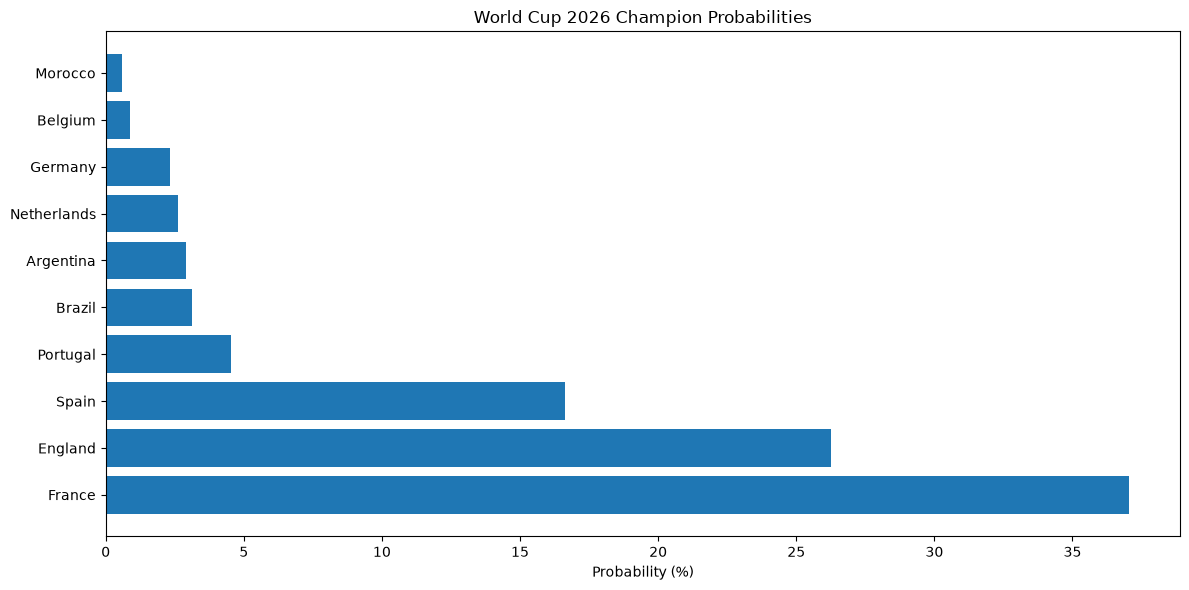

In [736]:
import matplotlib.pyplot as plt

top10 = results_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["Team"],
    top10["Title Probability (%)"]
)

plt.xlabel(
    "Probability (%)"
)

plt.title(
    "World Cup 2026 Champion Probabilities"
)

plt.tight_layout()

plt.show()

In [737]:
qualified_teams = (
    df_ratings
    .sort_values(
        "team_rating",
        ascending=False
    )
    .head(48)
)

qualified_teams[
    ["name", "team_rating"]
]

,name,team_rating
32,France,1.000000
28,England,0.946886
30,Spain,0.879597
29,Portugal,0.733461
31,Italy,0.707883
46,Brazil,0.697587
44,Argentina,0.696468
34,Netherlands,0.690745
27,Germany,0.687993
37,Belgium,0.595375


In [738]:
pots = np.array_split(
    qualified_teams["name"].tolist(),
    12
)

In [739]:
for i, pot in enumerate(pots, start=1):
    print(f"Pot {i}")
    print(list(pot))
    print()

Pot 1
[np.str_('France'), np.str_('England'), np.str_('Spain'), np.str_('Portugal')]

Pot 2
[np.str_('Italy'), np.str_('Brazil'), np.str_('Argentina'), np.str_('Netherlands')]

Pot 3
[np.str_('Germany'), np.str_('Belgium'), np.str_('Morocco'), np.str_('Senegal')]

Pot 4
[np.str_('Norway'), np.str_('Turkiye'), np.str_('Uruguay'), np.str_('United States')]

Pot 5
[np.str_('Denmark'), np.str_('Ecuador'), np.str_('Colombia'), np.str_('Switzerland')]

Pot 6
[np.str_('Croatia'), np.str_('Sweden'), np.str_('Japan'), np.str_('Austria')]

Pot 7
[np.str_('Serbia'), np.str_('Ukraine'), np.str_('Algeria'), np.str_('Nigeria')]

Pot 8
[np.str_('Greece'), np.str_('Poland'), np.str_('Russia'), np.str_('Wales')]

Pot 9
[np.str_('South Korea'), np.str_('Mexico'), np.str_('Hungary'), np.str_('Scotland')]

Pot 10
[np.str_('Canada'), np.str_('Egypt'), np.str_('Czech Republic'), np.str_('Paraguay')]

Pot 11
[np.str_('Iran'), np.str_('Australia'), np.str_('Republic of Ireland'), np.str_('Slovakia')]

Pot 12


In [740]:
import random

def generate_random_groups(
    qualified_df
):

    teams = qualified_df["name"].tolist()

    random.shuffle(teams)

    groups = {}

    letters = [
        "A","B","C","D",
        "E","F","G","H",
        "I","J","K","L"
    ]

    for i in range(12):

        groups[f"Group {letters[i]}"] = (
            teams[i*4:(i+1)*4]
        )

    return groups

In [741]:
groups_auto = generate_random_groups(
    qualified_teams
)

groups_auto

{'Group A': ['Nigeria', 'Germany', 'Sweden', 'Portugal'],
 'Group B': ['United States',
  'South Korea',
  'Republic of Ireland',
  'Czech Republic'],
 'Group C': ['Hungary', 'Denmark', 'Australia', 'Ghana'],
 'Group D': ['Georgia', 'Slovenia', 'Netherlands', 'Argentina'],
 'Group E': ['Spain', 'Greece', 'Russia', 'Ukraine'],
 'Group F': ['Panama', 'Norway', 'Poland', 'Brazil'],
 'Group G': ['Morocco', 'Mexico', 'Wales', 'Belgium'],
 'Group H': ['Ecuador', 'Algeria', 'Slovakia', 'Italy'],
 'Group I': ['Switzerland', 'Croatia', 'Serbia', 'Uruguay'],
 'Group J': ['Turkiye', 'Egypt', 'Iran', 'Canada'],
 'Group K': ['Japan', 'Austria', 'England', 'Paraguay'],
 'Group L': ['Senegal', 'France', 'Scotland', 'Colombia']}

In [742]:
df_ratings = prepare_team_data(df)
rating_dict = dict(
    zip(
        df_ratings["name_clean"],
        df_ratings["team_rating"]
    )
)

In [743]:
rating_dict["brazil"]

0.6975870953119219

In [744]:
def get_rating(team_name):

    return rating_dict.get(
        str(team_name).lower(),
        np.median(
            list(rating_dict.values())
        )
    )

In [745]:
get_rating("brazil")

0.6975870953119219

In [758]:
DEFAULT_RATING = np.median(
    list(rating_dict.values())
)

In [759]:
def get_rating(team_name):

    return rating_dict.get(
        str(team_name).lower(),
        DEFAULT_RATING
    )

In [760]:
import time

start = time.time()

for _ in range(10000):

    match_probabilities(
        "brazil",
        "argentina"
    )

end = time.time()

print(
    "Execution Time:",
    end - start
)

Execution Time: 0.08761167526245117


In [761]:
tournament_stats = {}

In [762]:
df_ratings.sort_values(
    "team_rating",
    ascending=False
)[
    ["name", "team_rating"]
].head(20)

,name,team_rating
32,France,1.000000
28,England,0.946886
30,Spain,0.879597
29,Portugal,0.733461
31,Italy,0.707883
46,Brazil,0.697587
44,Argentina,0.696468
34,Netherlands,0.690745
27,Germany,0.687993
37,Belgium,0.595375


In [763]:
match_probabilities(
    "Portugal",
    "San Marino"
)

(np.float64(0.9681166570710646),
 np.float64(0.007152645523577494),
 np.float64(0.024730697405357778))

In [764]:
match_probabilities(
    "Brazil",
    "Argentina"
)

(np.float64(0.36179060349943337),
 np.float64(0.2784375932676248),
 np.float64(0.3597718032329418))

In [765]:
results_df.head(10)


,Team,Titles,Title Probability (%),Std Error
0,France,3704,37.04,0.004829
2,England,2624,26.24,0.004399
1,Spain,1664,16.64,0.003724
7,Portugal,455,4.55,0.002084
9,Brazil,311,3.11,0.001736
11,Argentina,291,2.91,0.001681
6,Netherlands,263,2.63,0.001600
5,Germany,232,2.32,0.001505
4,Belgium,89,0.89,0.000939
8,Morocco,60,0.60,0.000772


In [766]:
results_df[
    "Title Probability (%)"
].sum()

np.float64(100.00000000000003)

In [767]:
missing = []

for team in groups_2026.values():

    for t in team:

        if str(t).lower() not in rating_dict:

            missing.append(t)

missing

['South Korea',
 'Bosnia and Herzegovina',
 'Haiti',
 'Curacao',
 'Ivory Coast',
 'Cabo Verde',
 'Congo DR']

In [768]:
name_mapping = {

    "usa": "united states",

    "south korea": "republic of korea",

    "ivory coast": "côte d'ivoire",

    "turkiye": "turkey"
}

In [769]:
results_df.to_csv(
    "../outputs/final_world_cup_2026_predictions.csv",
    index=False
)

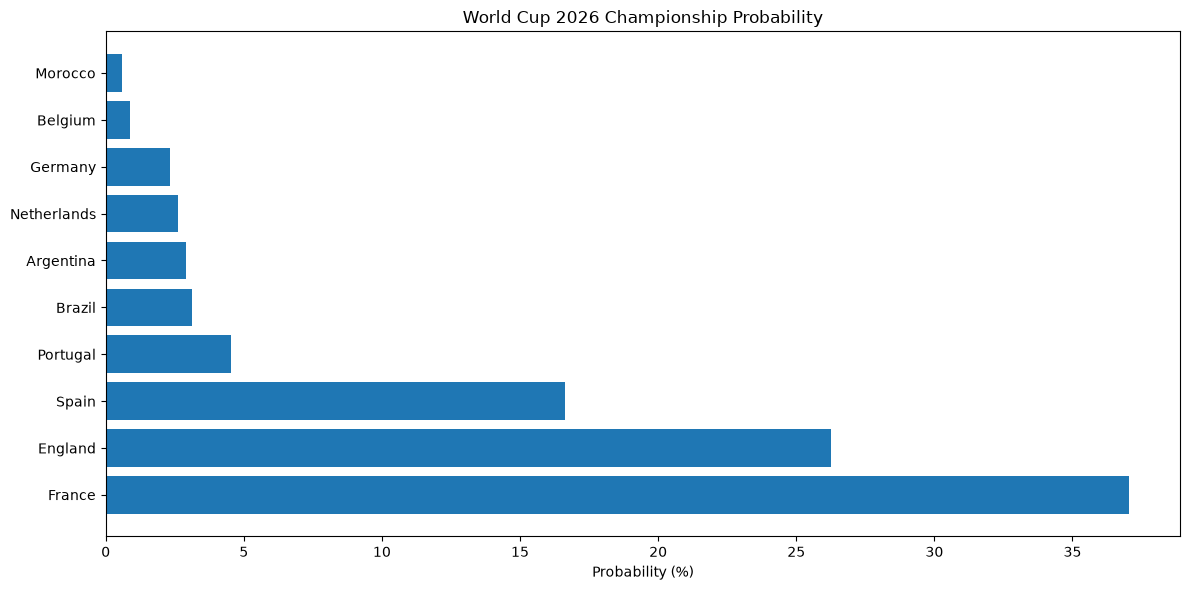

In [770]:
plt.figure(figsize=(12,6))

top10 = results_df.head(10)

plt.barh(
    top10["Team"],
    top10["Title Probability (%)"]
)

plt.xlabel("Probability (%)")
plt.title("World Cup 2026 Championship Probability")

plt.tight_layout()
plt.show()

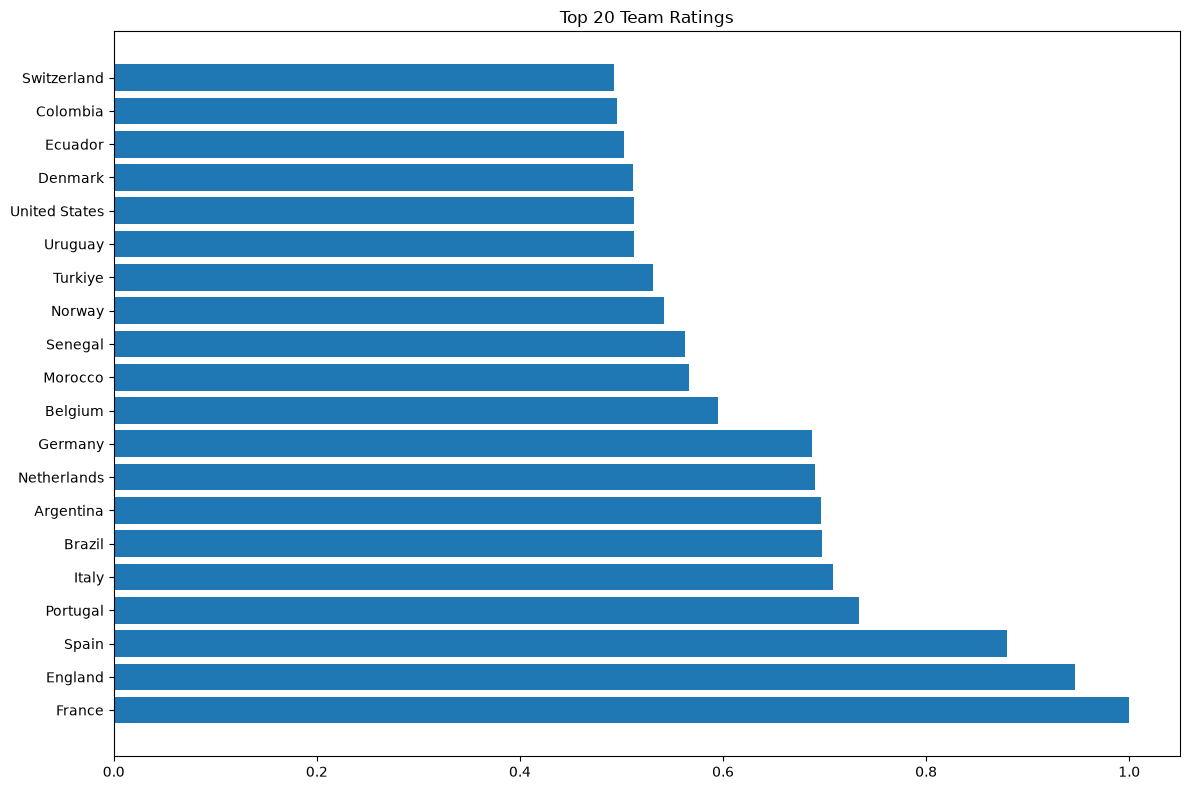

In [771]:
top20 = (
    df_ratings
    .sort_values(
        "team_rating",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12,8))

plt.barh(
    top20["name"],
    top20["team_rating"]
)

plt.title("Top 20 Team Ratings")
plt.tight_layout()

plt.show()

In [772]:
results_df["Title Probability (%)"].sum()

np.float64(100.00000000000003)

In [773]:
results_df["Titles"].sum()

np.int64(10000)

In [774]:

results_df.head(20)

,Team,Titles,Title Probability (%),Std Error
0,France,3704,37.04,0.004829
2,England,2624,26.24,0.004399
1,Spain,1664,16.64,0.003724
7,Portugal,455,4.55,0.002084
9,Brazil,311,3.11,0.001736
11,Argentina,291,2.91,0.001681
6,Netherlands,263,2.63,0.001600
5,Germany,232,2.32,0.001505
4,Belgium,89,0.89,0.000939
8,Morocco,60,0.60,0.000772
